In [1]:
# Q8

D:\anaconda\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


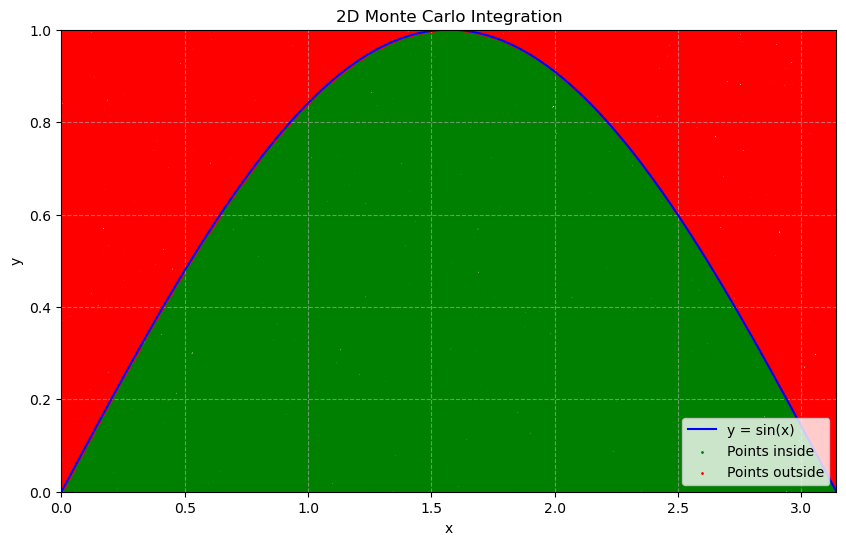

Number of random points: 500000
Actual Integral of sin(x) from 0 to π: 2.0
1D Monte Carlo Integration Result: 2.000343
Error (1D): 0.000343
2D Monte Carlo Integration Result: 2.002979
Error (2D): 0.002979


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------------------------
# 1️⃣ Define the function to integrate
# ---------------------------------------------------
def f(x):
    """
    Function to integrate.
    Here: f(x) = sin(x)
    """
    return np.sin(x)

# Integration limits
a = 0        # Lower limit
b = np.pi    # Upper limit

# Total number of random points for Monte Carlo simulation
num_points = 500_000

# ---------------------------------------------------
# 2️⃣ 1D Monte Carlo Integration
# ---------------------------------------------------
# Generate random x-values uniformly between a and b
x_random_1d = np.random.uniform(a, b, num_points)

# Evaluate f(x) at random points and take the mean
y_mean = np.mean(f(x_random_1d))

# Multiply mean value by (b - a) to get integral estimate
# Formula: integral ≈ (b - a) * mean(f(x_random))
integral_1d = (b - a) * y_mean

# ---------------------------------------------------
# 3️⃣ 2D Monte Carlo Integration (Geometric Approach)
# ---------------------------------------------------
# Define y-range for bounding box
y_min = 0
y_max = 1   # sin(x) is always between 0 and 1 in [0, pi]

# Area of bounding rectangle
area_of_box = (b - a) * (y_max - y_min)

# Generate random points in the 2D box [a,b] x [y_min, y_max]
x_random_2d = np.random.uniform(a, b, num_points)
y_random_2d = np.random.uniform(y_min, y_max, num_points)

# Count points that fall below the curve y = f(x)
points_under_curve = np.sum(y_random_2d <= f(x_random_2d))

# Estimate integral using fraction of points below curve
# Formula: integral ≈ area_of_box * (points_under_curve / total_points)
integral_2d = area_of_box * (points_under_curve / num_points)

# ---------------------------------------------------
# 4️⃣ Visualization: Points inside vs outside the curve
# ---------------------------------------------------
points_inside = y_random_2d <= f(x_random_2d)  # Boolean array: True if point is under curve

# Separate points for plotting
x_inside = x_random_2d[points_inside]
y_inside = y_random_2d[points_inside]
x_outside = x_random_2d[~points_inside]  # Points outside the curve
y_outside = y_random_2d[~points_inside]

# Generate smooth curve for plotting
x_plot = np.linspace(a, b, 1000)
y_plot = f(x_plot)

plt.figure(figsize=(10, 6))
# Plot the curve y = sin(x)
plt.plot(x_plot, y_plot, color='blue', label='y = sin(x)')
# Plot points inside the curve in green
plt.scatter(x_inside, y_inside, color='green', s=1, label='Points inside')
# Plot points outside the curve in red
plt.scatter(x_outside, y_outside, color='red', s=1, label='Points outside')

# Add title, labels, legend, and grid
plt.title('2D Monte Carlo Integration')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.axhline(0, color='black', linewidth=0.5)  # x-axis
plt.axvline(0, color='black', linewidth=0.5)  # y-axis
plt.xlim(a, b)
plt.ylim(y_min, y_max)
plt.show()

# ---------------------------------------------------
# 5️⃣ Display results
# ---------------------------------------------------
actual_value = 2.0  # Analytical integral of sin(x) from 0 to pi

print(f"Number of random points: {num_points}")
print(f"Actual Integral of sin(x) from 0 to π: {actual_value}")
print(f"1D Monte Carlo Integration Result: {integral_1d:.6f}")
print(f"Error (1D): {abs(integral_1d - actual_value):.6f}")
print(f"2D Monte Carlo Integration Result: {integral_2d:.6f}")
print(f"Error (2D): {abs(integral_2d - actual_value):.6f}")
